# Punto 6 (1.4) — El Reto

Encuentra una combinación de hasta 4 transformaciones sucesivas y sin repetir (escala de grises, negativo, gamma, logarítmica, lineal a trozos) aplicadas a `images/Input.tif` que logren un SSIM ≥ ~95% respecto a `images/Output.tif`. La imagen de salida solo se usa para comparar el resultado final, no para el proceso.

Recomendaciones: revisa las dimensiones de las imágenes e identifica efectos similares a los generados por las transformaciones vistas en el curso.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim

import sys
sys.path.append("..")
from utils import gamma_transform, log_transform, piecewise_linear, negative_transform


## Carga de imágenes



In [2]:
input_img = np.array(Image.open("../images/Input.tif").convert("RGB"))
output_ref = np.array(Image.open("../images/Output.tif").convert("L"))
print(input_img.shape, output_ref.shape)


(832, 1248, 3) (832, 1248)


## Exploración / pruebas de transformaciones

Ve probando transformaciones sucesivas aquí (usa las funciones de utils.py como base o escribe las tuyas).

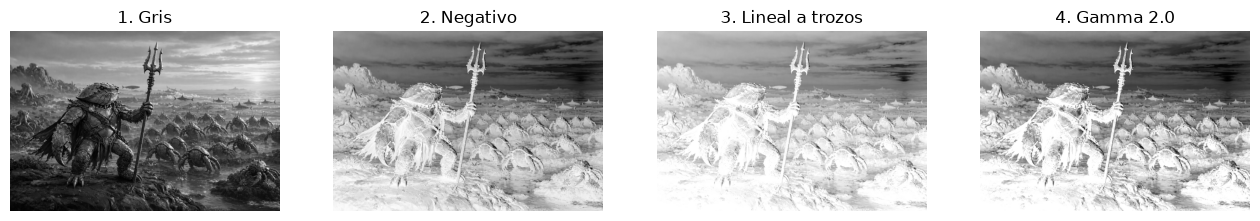

In [3]:
# Escala de grises (paso obligatorio inicial, la referencia es en gris)
gray0 = np.array(Image.fromarray(input_img).convert("L"))

# Cadena de transformaciones encontrada:
# 1) negativo -> 2) lineal a trozos -> 3) gamma
paso1 = negative_transform(gray0)
paso2 = piecewise_linear(paso1, r1=30, s1=100, r2=220, s2=255)
resultado = gamma_transform(paso2, 2.0)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, title in zip(
    axs,
    [gray0, paso1, paso2, resultado],
    ["1. Gris", "2. Negativo", "3. Lineal a trozos", "4. Gamma 2.0"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


## Evaluación con SSIM



In [4]:
from skimage.metrics import structural_similarity as ssim

score = ssim(resultado, output_ref)
print(f"SSIM: {score:.4f}")


SSIM: 0.9775


## Mejor aproximación

SSIM obtenido: **0.9775** (~97.75%)

Cadena de transformaciones aplicada sobre Input.tif: escala de grises -> negativo -> lineal a trozos (r1=30, s1=100, r2=220, s2=255) -> gamma (gamma=2.0).

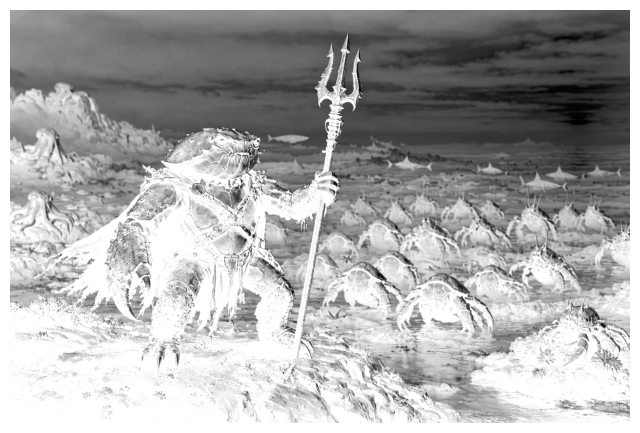

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(resultado, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.savefig("../results/punto6_mejor_aproximacion.png", bbox_inches="tight", pad_inches=0)
